# Freight Rate Prediction: EDA and Model-Selection Evidence

This notebook is a concise reviewer-facing record. Production feature engineering and leakage-clean temporal evaluation live in `src/`; this notebook does not fit preprocessing on future rows.

## 1. Imports and data loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

DATA_DIR = Path("../data")
train = pd.read_csv(DATA_DIR / "train-test.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
december = pd.read_csv(DATA_DIR / "december-chart-inputs.csv")
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
december["date"] = pd.to_datetime(december["date"])

## 2. Dataset overview

In [2]:
overview = pd.DataFrame({
    "rows": [len(train), len(validation), len(december)],
    "columns": [train.shape[1], validation.shape[1], december.shape[1]],
    "date_min": [train["date"].min(), validation["date"].min(), december["date"].min()],
    "date_max": [train["date"].max(), validation["date"].max(), december["date"].max()],
}, index=["train", "validation", "december"])
display(overview)
display(train.dtypes.rename("dtype").to_frame())

,rows,columns,date_min,date_max
train,48000,14,2025-01-01,2025-10-31
validation,12000,13,2025-11-01,2025-12-31
december,31,7,2025-12-01,2025-12-31


,dtype
load_id,object
pickup,object
delivery,object
pickup_lat,float64
pickup_lon,float64
delivery_lat,float64
delivery_lon,float64
distance,float64
equipment,object
weight,float64


## 3. Data quality

In [3]:
quality = pd.Series({
    "duplicate_rows": int(train.duplicated().sum()),
    "missing_weight": int(train["weight"].isna().sum()),
    "negative_weight": int((train["weight"] < 0).sum()),
    "missing_market_index": int(train["market_index"].isna().sum()),
})
display(quality.rename("count").to_frame())
display(train["posted_rate"].describe().rename("posted_rate").to_frame())

,count
duplicate_rows,0
missing_weight,300
negative_weight,292
missing_market_index,374


,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


## 4. Target exploration

`posted_rate` is right-skewed with a small extreme tail. MAE is used as the primary selection metric because it is less dominated by rare large values than squared-error objectives.

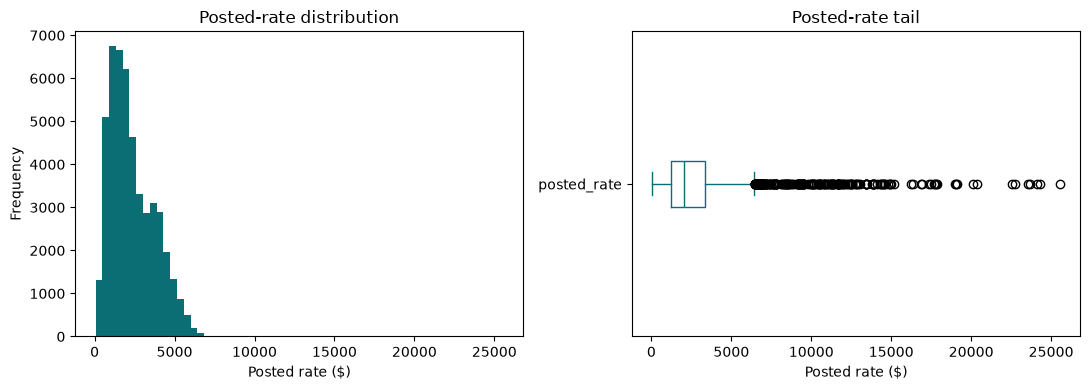

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
train["posted_rate"].plot.hist(bins=60, ax=axes[0], color="#0B6E75")
axes[0].set_title("Posted-rate distribution")
axes[0].set_xlabel("Posted rate ($)")
train["posted_rate"].plot.box(ax=axes[1], vert=False, color="#0B6E75")
axes[1].set_title("Posted-rate tail")
axes[1].set_xlabel("Posted rate ($)")
plt.tight_layout()
plt.show()

## 5. Baseline exploration

,validation_month,MAE
0,August,317.26
1,September,71.75
2,October,413.72


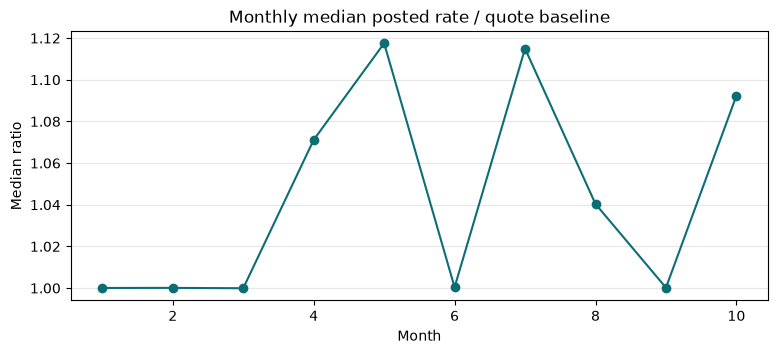

In [5]:
train["quote_base_rate"] = train["distance"] * train["quote_signal"]
baseline_folds = []
for month, start, end in [
    ("August", "2025-08-01", "2025-09-01"),
    ("September", "2025-09-01", "2025-10-01"),
    ("October", "2025-10-01", "2025-11-01"),
]:
    fold = train[(train["date"] >= start) & (train["date"] < end)]
    baseline_folds.append({
        "validation_month": month,
        "MAE": mean_absolute_error(fold["posted_rate"], fold["quote_base_rate"]),
    })
display(pd.DataFrame(baseline_folds).round(2))

train["quote_ratio"] = train["posted_rate"] / train["quote_base_rate"]
monthly_ratio = train.groupby(train["date"].dt.month)["quote_ratio"].median()
monthly_ratio.plot(marker="o", figsize=(9, 3.5), color="#0B6E75")
plt.title("Monthly median posted rate / quote baseline")
plt.xlabel("Month")
plt.ylabel("Median ratio")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Temporal split rationale

Training ends on 2025-10-31 and hidden validation begins on 2025-11-01. A random split would mix later observations into model development and would not simulate inference on future loads. The final evaluation therefore uses expanding windows: train on all earlier dates and validate on August, September, and October. Preprocessing statistics are fitted separately on each fold's training portion.

## 7. Model comparison

In [6]:
comparison = pd.DataFrame([
    ("Quote Baseline", "Reference; unstable across months"),
    ("HistGB Direct", "Improved on baseline; weaker than CatBoost"),
    ("HistGB Residual", "Less stable than direct prediction"),
    ("CatBoost Direct", "Best model family; selected"),
    ("CatBoost Residual", "No consistent benefit over direct CatBoost"),
], columns=["model", "verified selection finding"])
display(comparison)

depth_summary = pd.DataFrame({
    "depth": [6, 8, 10],
    "selection_result": [
        "Lowest mean temporal MAE; selected",
        "Worse mean temporal MAE than depth 6",
        "Worse mean temporal MAE than depth 6",
    ],
})
display(depth_summary)

,model,verified selection finding
0,Quote Baseline,Reference; unstable across months
1,HistGB Direct,Improved on baseline; weaker than CatBoost
2,HistGB Residual,Less stable than direct prediction
3,CatBoost Direct,Best model family; selected
4,CatBoost Residual,No consistent benefit over direct CatBoost


,depth,selection_result
0,6,Lowest mean temporal MAE; selected
1,8,Worse mean temporal MAE than depth 6
2,10,Worse mean temporal MAE than depth 6


## 8. Final leakage-clean temporal validation

The table below is generated by `python -m src.evaluate`. It supersedes all earlier exploratory metrics.

In [7]:
final_metrics = pd.read_csv("../outputs/final_temporal_metrics.csv")
display(final_metrics[["fold", "MAE", "RMSE", "R2", "best_iteration"]].round(4))
display(final_metrics[["MAE", "RMSE", "R2"]].mean().rename("mean").round(4).to_frame())

,fold,MAE,RMSE,R2,best_iteration
0,2025-08,92.2755,613.1818,0.8271,1396
1,2025-09,107.6721,617.9390,0.8354,904
2,2025-10,118.1789,648.3414,0.8201,614


,mean
MAE,106.0422
RMSE,626.4874
R2,0.8276


## 9. Final modeling conclusion

The final model is direct `CatBoostRegressor` with depth 6, learning rate 0.05, 1,050 iterations, L2 regularization 5, and MAE loss. It uses the smaller common feature set: pickup, delivery, equipment, lane, distance, weight, and date-derived features. This configuration produced the strongest leakage-clean out-of-time results and uses only fields available in both validation and fixed December inference. Market, quote, and coordinate features remain EDA/experiment inputs only and are intentionally excluded from production.